# 折線圖 Line Plot：把生活中的變化畫出來

今天要解決的問題很實際：月底錢跑去哪裡？早十分鐘出門有比較快嗎？想去健身房又怕排隊，該挑哪個時段？早餐店該在哪幾天多備料？

折線圖把「依順序發生的事情」排在一起，讓我們比較變化。學完不是只會把線畫出來，而是能說明：每個點代表誰、哪一天、什麼數值；線往上代表什麼；這張圖能支持什麼決定，又還缺哪些資料。


## 第一部分：Matplotlib


### 範例：第一張飲料花費折線圖

你覺得手搖飲每天幾十元還好，但一週合起來呢？先不讀檔，直接用七筆數字建立第一張圖。
資料寫在程式內，`星期` 與 `飲料費` 的第 1 個元素要互相配對；兩個串列必須一樣長。

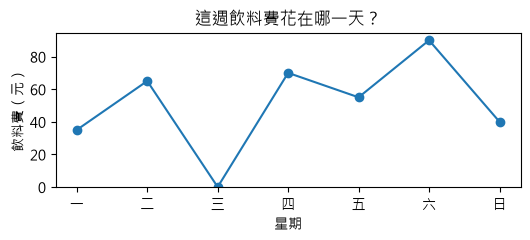

本週合計： 355 元


In [ ]:
import matplotlib.pyplot as plt


星期 = ["一", "二", "三", "四", "五", "六", "日"]
飲料費 = [35, 65, 0, 70, 55, 90, 40]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	fig, ax = plt.subplots(figsize=(6, 2))
	ax.plot(星期, 飲料費, marker="o")
	ax.set(title="這週飲料費花在哪一天？", xlabel="星期", ylabel="飲料費（元）")
	ax.set_ylim(bottom=0)
	plt.show()
	print("本週合計：", sum(飲料費), "元")

# - `plt.subplots()` 回傳兩個物件：`fig` 是整張畫紙，`ax` 是畫紙中的座標區。左邊 `fig, ax =` 把兩個結果各自接住。
# - `ax.plot(x, y)` 按提供的順序連線；`marker="o"` 在真的有紀錄的位置加圓點。`ax.set(...)` 一次設定標題與軸名稱。`plt.show()` 顯示圖形，不負責計算花費。

### 範例：讀取飲料記帳CSV

獨立範例檔：[02_讀取飲料記帳CSV.py](./line_plot_examples/02_讀取飲料記帳CSV.py)

記帳通常存在試算表，而不是寫死在程式裡。本例檔案：`01_一週飲料花費.csv`。
先把 CSV 當作只有列、欄的表格：每列是一天，每欄是這一天的一項資訊。


  星期  飲料費
0  一    0
1  二   65
2  三   45
3  四    0
4  五   75
5  六  110
6  日    0


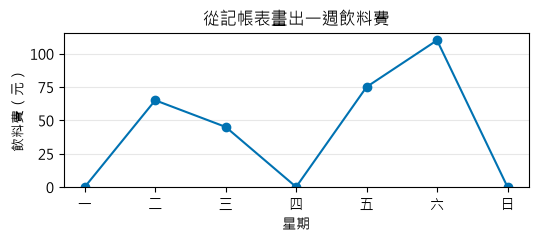

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/一週飲料花費.csv", encoding="utf-8-sig")
print(df)

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 2))
	ax.plot(df["星期"], df["飲料費"], marker="o", color="#0072B2")
	ax.set(title="從記帳表畫出一週飲料費", xlabel="星期", ylabel="飲料費（元）")
	ax.set_ylim(bottom=0) # 設定 Y 軸的最小值從 0 開始
	ax.grid(axis="y", alpha=0.3)
	plt.show()


### 範例：標記線型與圖例


  星期  飲料費
0  一    0
1  二   65
2  三   45
3  四    0
4  五   75
5  六  110
6  日    0


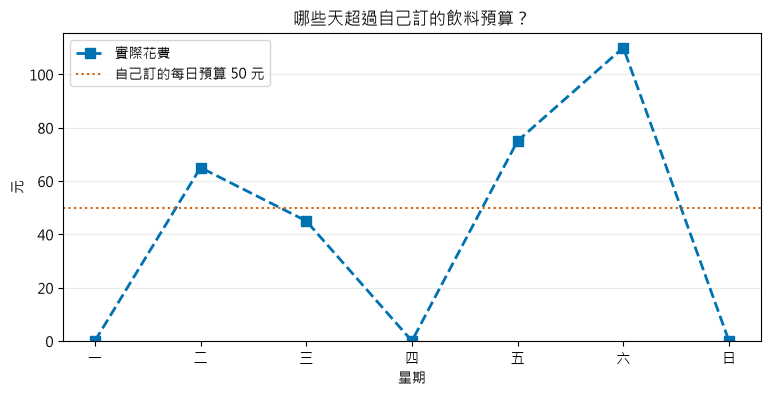

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/一週飲料花費.csv", encoding="utf-8-sig")
print(df)

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 4))
	ax.plot(df["星期"], df["飲料費"], color="#0072B2", linewidth=2, linestyle="--", marker="s", markersize=7, label="實際花費")
	# 在 Y=50 的位置畫一條水平虛線，表示每日預算基準線
	ax.axhline(50, color="#D55E00", linestyle=":", label="自己訂的每日預算 50 元")
	ax.set(title="哪些天超過自己訂的飲料預算？", xlabel="星期", ylabel="元")
	ax.set_ylim(bottom=0)
	ax.legend()
	ax.grid(axis="y", alpha=0.25)
	plt.show()


### 範例：通勤路線誰快誰穩

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/通勤兩條路線.csv", encoding="utf-8-sig")
df

,日期,公車,捷運
0,2026-04-06,42,31
1,2026-04-07,48,29
2,2026-04-08,39,34
3,2026-04-09,55,32
4,2026-04-10,46,30


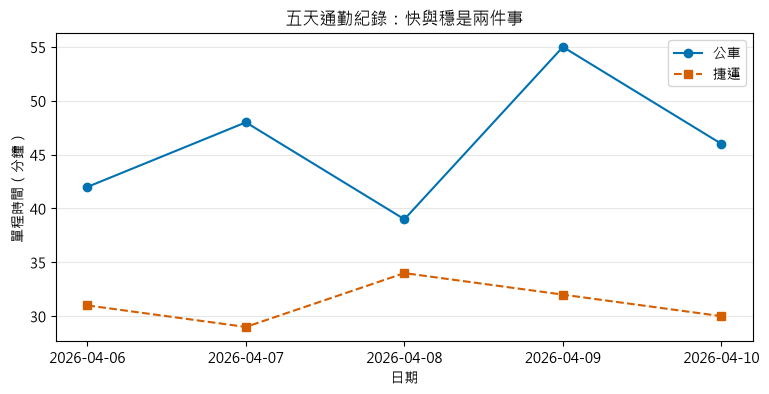

        公車    捷運
mean  46.0  31.2
min   39.0  29.0
max   55.0  34.0


In [ ]:
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 4))
	ax.plot(df["日期"], df["公車"], marker="o", label="公車", color="#0072B2")
	ax.plot(df["日期"], df["捷運"], marker="s", linestyle="--", label="捷運", color="#D55E00")
	ax.set(title="五天通勤紀錄：快與穩是兩件事", xlabel="日期", ylabel="單程時間（分鐘）")
	ax.legend()
	ax.grid(axis="y", alpha=0.3)
	plt.show()
	print(df[["公車", "捷運"]].agg(["mean", "min", "max"]).round(1))

### 範例：健身房避開人潮

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/健身房人潮.csv", encoding="utf-8-sig")
df

,時刻,平日人數,假日人數
0,6,12,8
1,8,24,18
2,10,18,45
3,12,25,62
4,14,20,70
5,16,38,65
6,18,78,58
7,20,90,43
8,22,40,22


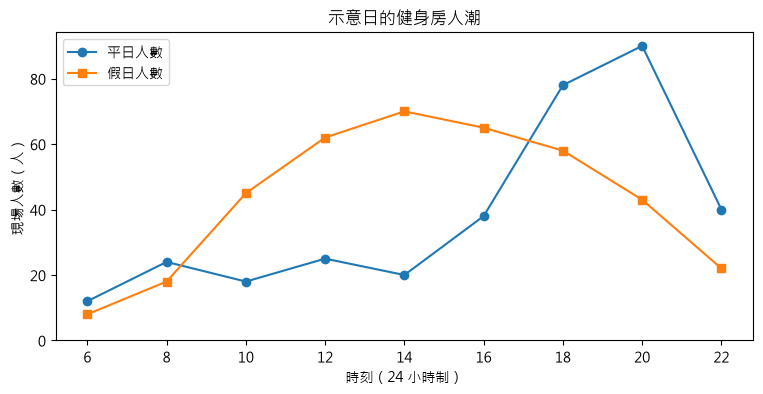

時刻       6
平日人數    12
Name: 0, dtype: int64


In [ ]:
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 4))

	# `for` 表示「將同樣步驟對不同欄位各做一次」。每圈拿到欄名與標記，再呼叫 `plot`。先看懂兩次手寫的版本，再用迴圈減少重複。
	for column, marker in [("平日人數", "o"), ("假日人數", "s")]:
		ax.plot(df["時刻"], df[column], marker=marker, label=column) # 分別繪製平日與假日人數折線，並使用不同的資料點形狀
	ax.set_xticks(df["時刻"])
	ax.set(title="示意日的健身房人潮", xlabel="時刻（24 小時制）", ylabel="現場人數（人）")
	ax.set_ylim(bottom=0)
	ax.legend()
	plt.show()
	print(df.loc[df["平日人數"].idxmin(), ["時刻", "平日人數"]])


### 範例：同一資料不同座標範圍

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/超市雞蛋價格.csv", encoding="utf-8-sig")
df

,週次,甲超市,乙超市
0,1,65,68
1,2,65,68
2,3,69,68
3,4,69,70
4,5,72,70
5,6,72,70
6,7,68,70
7,8,68,66


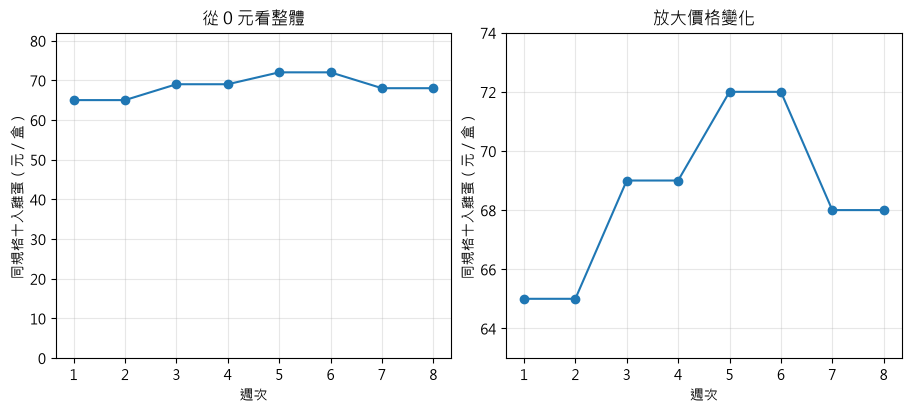

最大與最小差： 7 元


In [ ]:
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1,2,figsize=(9, 4), layout="constrained") # 自動調整圖表元素間距，避免標題、座標軸文字被擠壓或超出畫布
	for ax in axes:
		ax.plot(df["週次"], df["甲超市"], marker="o")
		ax.set(xlabel="週次", ylabel="同規格十入雞蛋（元／盒）")
		ax.grid(alpha=0.3)
		axes[0].set(title="從 0 元看整體", ylim=(0, df["甲超市"].max() + 10))
		axes[1].set(title="放大價格變化", ylim=(df["甲超市"].min() - 2, df["甲超市"].max() + 2))
	plt.show()
print("最大與最小差：", df["甲超市"].max() - df["甲超市"].min(), "元")


### 範例：亂序日期造成折返線

獨立範例檔：[07_亂序日期造成折返線.py](./line_plot_examples/07_亂序日期造成折返線.py)

資料檔：`04_亂序飲料記帳.csv`。月底補登記帳，輸入順序不是消費順序。


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/亂序飲料記帳.csv", encoding="utf-8-sig")
df

,日期,飲料費
0,2026-04-03,80
1,2026-04-01,40
2,2026-04-04,60
3,2026-04-02,50


In [22]:
ordered = df.sort_values("日期")
ordered

,日期,飲料費
1,2026-04-01,40
3,2026-04-02,50
0,2026-04-03,80
2,2026-04-04,60


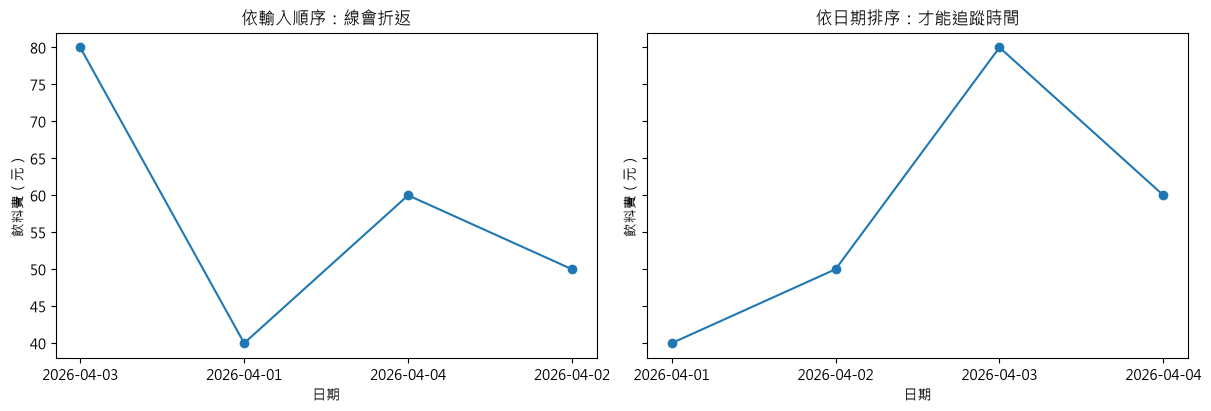

In [ ]:
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, layout="constrained")
	axes[0].plot(df["日期"], df["飲料費"], marker="o")
	axes[1].plot(ordered["日期"], ordered["飲料費"], marker="o")
	for ax, title in zip(axes, ["依輸入順序：線會折返", "依日期排序：才能追蹤時間"]):
		ax.set(title=title, xlabel="日期", ylabel="飲料費（元）")
	plt.show()


### 範例：不等間隔日期與文字日期

In [ ]:
df = pd.DataFrame(
	{"日期": ["2026-04-01", "2026-04-02", "2026-04-10"], 
	 "飲料費": [40, 60, 50]
	}
)
df

,日期,飲料費
0,2026-04-01,40
1,2026-04-02,60
2,2026-04-10,50


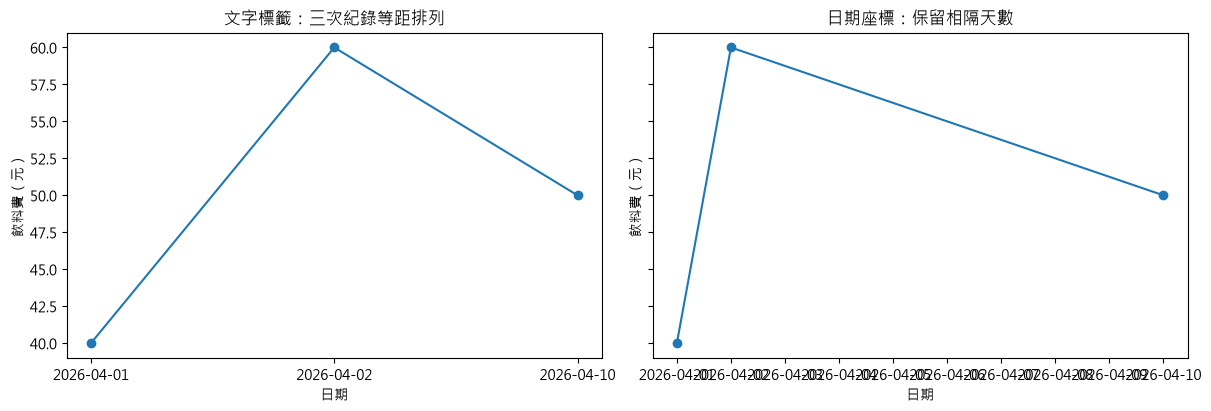

In [ ]:
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, layout="constrained")
	# sharey=True 多張子圖共用同一套 Y 軸範圍
	axes[0].plot(df["日期"], df["飲料費"], marker="o")
	axes[0].set_title("文字標籤：三次紀錄等距排列")
	axes[1].plot(pd.to_datetime(df["日期"]), df["飲料費"], marker="o")
	axes[1].set_title("日期座標：保留相隔天數")
	for ax in axes:
		ax.set(xlabel="日期", ylabel="飲料費（元）")
	plt.show()

### 範例：訂單金額先整理成每日營業額

在"./Data_Visualization_data/早餐店交易.csv"中，每列是一張訂單。同一天有三筆不是重複錯誤；老闆問一天賣多少錢，需要加總。

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/早餐店交易.csv", encoding="utf-8-sig")
df

,日期,訂單金額
0,2026-04-01,60
1,2026-04-01,80
2,2026-04-01,70
3,2026-04-02,90
4,2026-04-02,110
5,2026-04-03,50
6,2026-04-03,65
7,2026-04-03,75
8,2026-04-03,90


In [ ]:
daily = df.groupby("日期", as_index=False).agg(
		營業額=("訂單金額", "sum"), 
		平均每單金額=("訂單金額", "mean"), 
		訂單數=("訂單金額", "size")
	)
daily

,日期,營業額,平均每單金額,訂單數
0,2026-04-01,210,70.0,3
1,2026-04-02,200,100.0,2
2,2026-04-03,280,70.0,4


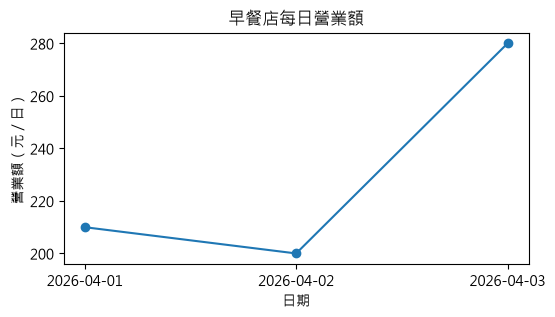

In [ ]:
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 3))
	ax.plot(daily["日期"], daily["營業額"], marker="o")
	ax.set(title="早餐店每日營業額", xlabel="日期", ylabel="營業額（元／日）")
	plt.show()

### 範例：每日餐費與累積花費

"./Data_Visualization_data/一個月餐費.csv"。月底預算會不會用完？每天吃多少與到今天共花多少，必須分清楚。

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/一個月餐費.csv", encoding="utf-8-sig")
df.head()

,日期,餐費
0,2026-04-01,235
1,2026-04-02,260
2,2026-04-03,220
3,2026-04-04,310
4,2026-04-05,380


In [44]:
df["累積餐費"] = df["餐費"].cumsum() # 累積
df.head()

,日期,餐費,累積餐費
0,2026-04-01,235,235
1,2026-04-02,260,495
2,2026-04-03,220,715
3,2026-04-04,310,1025
4,2026-04-05,380,1405


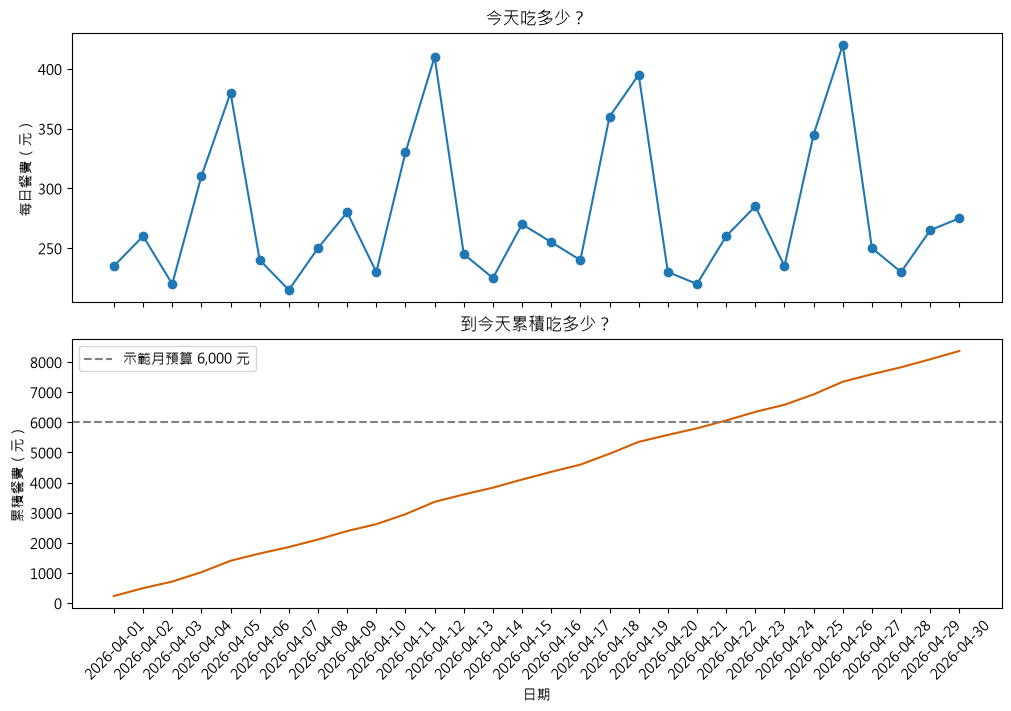

全月餐費： 8365 元


In [ ]:
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")
	ax[0].plot(df["日期"], df["餐費"], marker="o")
	ax[0].set(title="今天吃多少？", ylabel="每日餐費（元）")
	ax[1].plot(df["日期"], df["累積餐費"], color="#D55E00")
	ax[1].axhline(6000, linestyle="--", color="gray", label="示範月預算 6,000 元")
	ax[1].set(title="到今天累積吃多少？", xlabel="日期", ylabel="累積餐費（元）")
	ax[1].tick_params(axis="x", rotation=45) # 將 X 軸日期旋轉 45 度，避免文字重疊
	ax[1].legend()
	plt.show()
print("全月餐費：", df["餐費"].sum(), "元")


### 範例：標出高點與超標區域

"./Data_Visualization_data/一個月餐費.csv"。與其每個點都寫數字，不如標示最高的一天與自己設定的 250 元預算。

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/一個月餐費.csv", encoding="utf-8-sig")
df.head()

,日期,餐費
0,2026-04-01,235
1,2026-04-02,260
2,2026-04-03,220
3,2026-04-04,310
4,2026-04-05,380


In [49]:
budget = 250
peak = df.loc[df["餐費"].idxmax()] # 找出當日最高預算，待會要用箭頭表示
peak

日期    2026-04-26
餐費           420
Name: 25, dtype: object

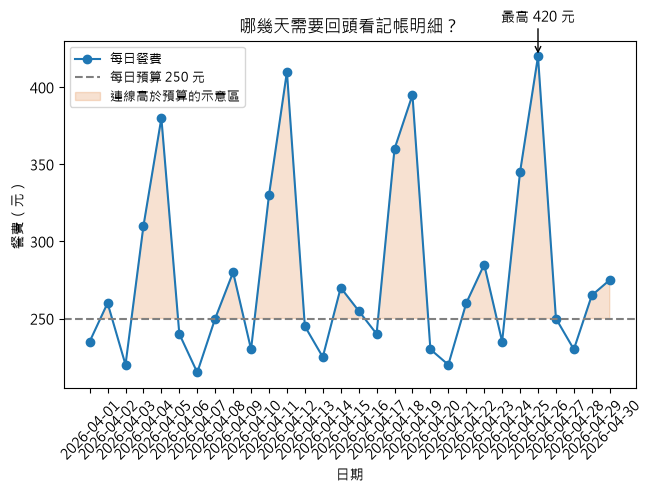

超支總額： 1100 元


In [ ]:
budget = 250 # 設定每日餐費預算為 250 元

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	# 建立 10×7 英吋的圖表，並自動調整版面間距
	fig, ax = plt.subplots(
		# figsize=(10, 7),
		layout="constrained"
	)

	# 繪製每日餐費折線圖
	ax.plot(
		df["日期"],
		df["餐費"],
		marker="o", # 每筆資料加上圓形標記
		label="每日餐費" # 設定圖例名稱
	)

	# 畫出每日預算 250 元的水平參考線
	ax.axhline(
		budget,
		color="gray", # 設定線條顏色為灰色
		linestyle="--", # 使用虛線
		label="每日預算 250 元"
	)

	# 將餐費超過預算的區域填滿，凸顯超支區間
	ax.fill_between(
		df["日期"],
		df["餐費"],
		budget,
		where=df["餐費"] > budget, # 只填滿餐費高於預算的區域
		interpolate=True, # 計算折線與預算線的交點，使填色邊界更自然
		alpha=0.18, # 設定填色透明度
		color="#D55E00",
		label="連線高於預算的示意區"
	)

	# 在最高餐費的位置加入文字與箭頭標註
	ax.annotate(
		f"最高 {peak['餐費']:.0f} 元", # 顯示最高餐費，格式化為整數
		xy=(peak["日期"], peak["餐費"]), # 箭頭指向最高餐費資料點
		xytext=(0, 25), # 文字相對資料點向上移動 25 points
		textcoords="offset points", # xytext 使用相對資料點的偏移量
		ha="center", # 文字水平置中
		arrowprops={"arrowstyle": "->"} # 使用箭頭指向資料點
	)

	# 設定圖表標題與座標軸名稱
	ax.set(
		title="哪幾天需要回頭看記帳明細？",
		xlabel="日期",
		ylabel="餐費（元）"
	)
	ax.tick_params(axis="x", rotation=45) # 將 X 軸日期旋轉 45 度，避免文字重疊

	# 顯示圖例
	ax.legend(
		loc="upper left", # 圖例放在左上角
		fontsize=9 # 圖例文字大小
	)
	plt.show()

# 計算每天超過 250 元的金額，再加總所有超支金額
print(
	"超支總額：",
	(df["餐費"] - budget).clip(lower=0).sum(),
	"元"
)

### 範例：不同單位先分成子圖

資料檔：`./Data_Visualization_data/每月用電.csv`。比較每月總用電與平均每日用電，練習避免把不同單位擠在同一條 y 軸。


In [63]:
import matplotlib.pyplot as plt
import pandas as pd

### 讀CSV
df = pd.read_csv("./Data_Visualization_data/每月用電.csv", encoding="utf-8-sig")
df.head()

,月份,用電度數
0,2025-01-01,180
1,2025-02-01,165
2,2025-03-01,175
3,2025-04-01,205
4,2025-05-01,260


In [67]:
# 確保「月份」是日期型態
df["月份"] = pd.to_datetime(df["月份"])
# 取得該月份有幾天
df["當月天數"] = df["月份"].dt.days_in_month
# 計算平均每天用電度數
df["每日平均"] = df["用電度數"] / df["當月天數"]
df

,月份,用電度數,當月天數,每日平均
0,2025-01-01,180,31,5.806452
1,2025-02-01,165,28,5.892857
2,2025-03-01,175,31,5.645161
3,2025-04-01,205,30,6.833333
4,2025-05-01,260,31,8.387097
5,2025-06-01,335,30,11.166667
6,2025-07-01,390,31,12.580645
7,2025-08-01,405,31,13.064516
8,2025-09-01,340,30,11.333333
9,2025-10-01,265,31,8.548387


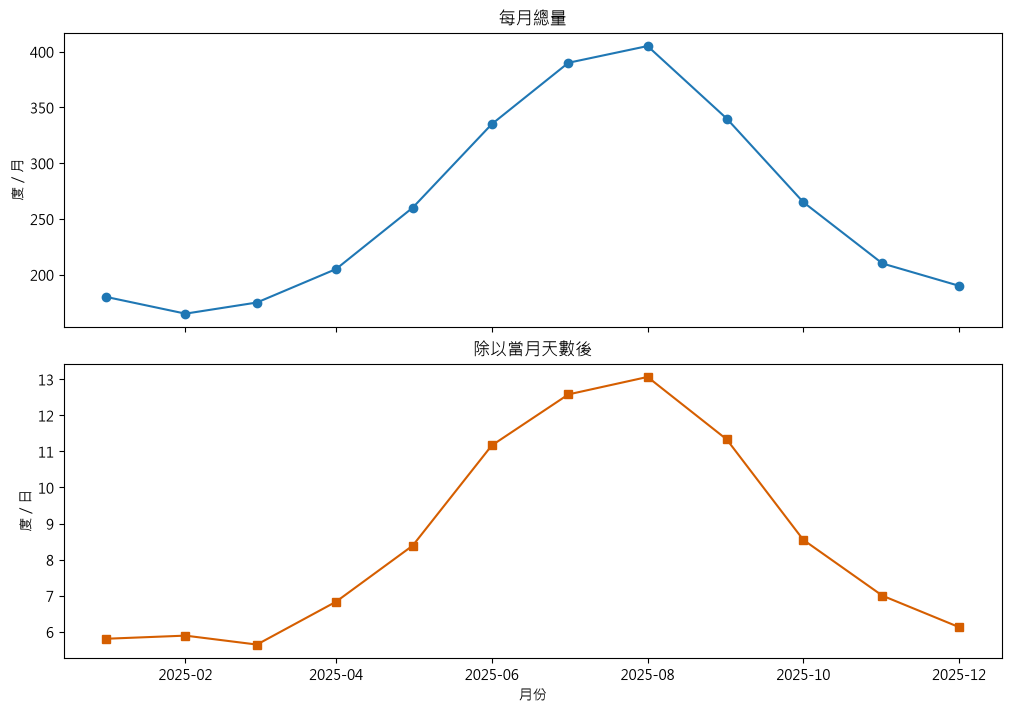

In [ ]:
import matplotlib.dates as mdates

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")

	axes[0].plot(df["月份"], df["用電度數"], marker="o")
	axes[0].set(title="每月總量", ylabel="度／月")

	axes[1].plot(df["月份"], df["每日平均"], marker="s", color="#D55E00")
	axes[1].set(title="除以當月天數後", ylabel="度／日", xlabel="月份")

	axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # 每隔 2 個月顯示一個刻度
	axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m")) # 日期顯示為「年-月」

	plt.show()




## 第二部分：使用 Seaborn 

Matplotlib 常由你提供一條線的 x、y；Seaborn 可以收到一整張表，再依欄位拆成多條線。兩者可以合作：`plt.subplots()` 建立畫布，`sns.lineplot(..., ax=ax)` 畫資料，`ax.set()` 調整標題。

**最需要留意的差異：Seaborn 的 `lineplot` 預設會在同一組、同一 x 位置取 y 的平均，並估計平均的不確定性；這不是單純把全部原始點接起來。** 同一天多張訂單、同一天多位同學、同一天多次抄表，所需處理可能完全不同。

| 參數 | 用白話理解 | 何時要特別確認 |
|---|---|---|
| `data` | 給哪張表格 | 每列代表什麼 |
| `x`, `y` | 用哪兩欄當座標 | 日期型別與 y 的單位 |
| `hue` | 依類別分顏色 | 是否需要固定顏色對照 |
| `style` | 依類別分線型與標記 | 黑白列印與顏色辨識 |
| `estimator` | 同一 x 多筆值要怎麼整理 | 平均、總和或原始個體 |
| `errorbar` | 陰影或誤差線代表什麼 | 不要把平均的不確定性當每個人的範圍 |
| `units` | 每條線是哪一位／哪個單位 | 搭配 `estimator=None` 保留個體 |
| `sort` | 是否先按 x 排序 | 預設排序不會替你把文字變日期 |


### 範例：Seaborn第一張餐費圖

畫出和第一部分同樣的餐費，熟悉「欄位名稱」寫法。

資料檔：`./Data_Visualization_data/一個月餐費.csv`。




In [2]:
import pandas as pd

df = pd.read_csv("./Data_Visualization_data/一個月餐費.csv")
df["日期"] = pd.to_datetime(df["日期"]) # 將日期欄位轉成 datetime

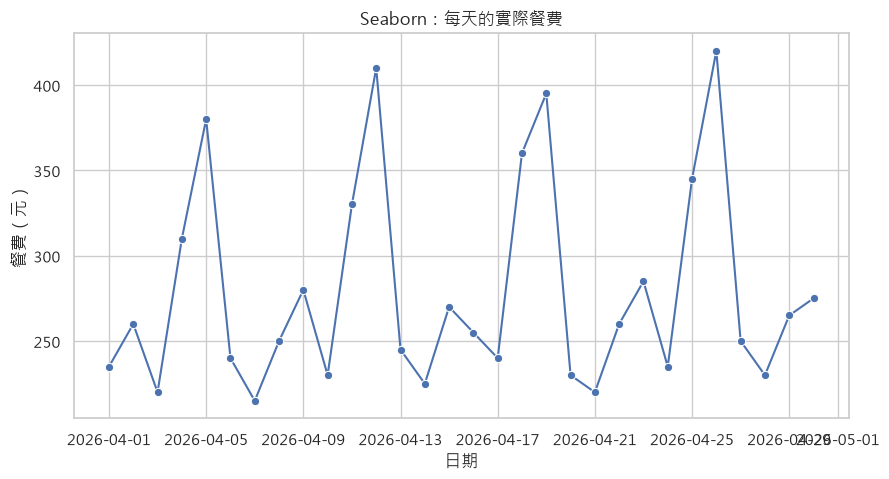

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


### 設定 Seaborn 全域主題
sns.set_theme(
	style="whitegrid", # 使用白色背景 + 格線
	font="Microsoft JhengHei", # 設定中文字型為微軟正黑體
	rc={"axes.unicode_minus": False} # 避免負號顯示異常
)

### 建立畫布
fig, ax = plt.subplots(figsize=(10, 5)) # 建立 10 × 5 英吋的圖表
### 繪製折線圖
sns.lineplot(
	data=df, # 使用 df DataFrame 作為資料來源
	x="日期", # X 軸使用「日期」欄位
	y="餐費", # Y 軸使用「餐費」欄位
	estimator=None, # 不進行平均等統計計算，直接呈現原始資料
	errorbar=None, # 不顯示誤差範圍
	marker="o", # 每個資料點使用圓形標記
	ax=ax # 將圖畫在前面建立的 ax 上
)

### 設定圖表資訊
ax.set(
	title="Seaborn：每天的實際餐費", # 圖表標題
	xlabel="日期", # X 軸名稱
	ylabel="餐費（元）" # Y 軸名稱
)
plt.show()

### 範例：午餐方式固定顏色與順序

獨立範例檔："./Data_Visualization_data/午餐取得方式.csv"

十天三種取得方式的情境費用，外送包含附加費，自備只計材料、不含工時。


In [ ]:
import pandas as pd

df = pd.read_csv("./Data_Visualization_data/午餐取得方式.csv")
df["日期"] = pd.to_datetime(df["日期"]) # 將「日期」轉成 datetime
df

,日期,自備便當,店內購買,外送到家
0,2026-04-06,65,110,165
1,2026-04-07,70,120,180
2,2026-04-08,60,105,160
3,2026-04-09,75,130,195
4,2026-04-10,68,115,170
5,2026-04-11,72,120,185
6,2026-04-12,66,110,165
7,2026-04-13,70,125,190
8,2026-04-14,65,115,175
9,2026-04-15,74,130,200


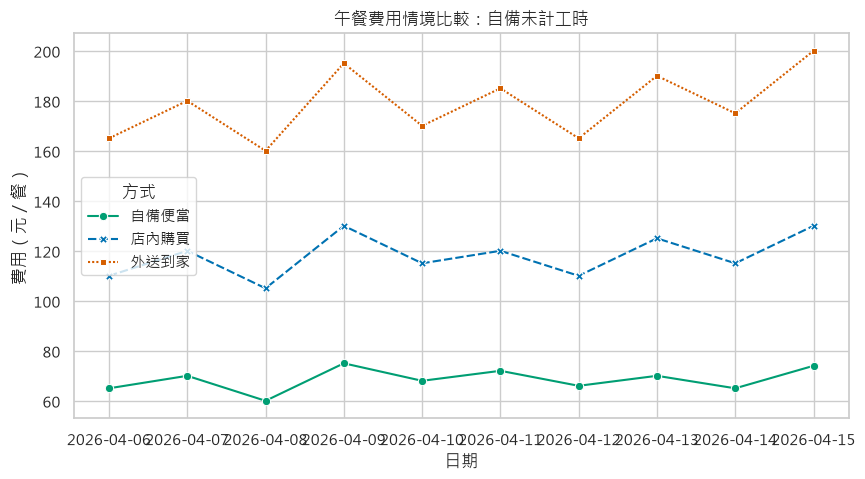

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### 將寬格式轉成長格式
methods = ["自備便當", "店內購買", "外送到家"]

long_df = df.melt(
	id_vars="日期", # 保留「日期」欄位不動
	value_vars=methods, # 將這三個欄位的資料往下堆疊
	var_name="方式", # 原本的欄位名稱存入「方式」
	value_name="費用" # 原本的數值存入「費用」
)


### 設定 Seaborn 主題
sns.set_theme(
	style="whitegrid",
	font="Microsoft JhengHei",
	rc={"axes.unicode_minus": False} # 避免負號顯示異常
)


### 固定三種方式的顏色
colors = {
	"自備便當": "#009E73",
	"店內購買": "#0072B2",
	"外送到家": "#D55E00"
}


### 繪製折線圖
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
	data=long_df,
	x="日期",
	y="費用",
	hue="方式", # 不同方式使用不同顏色
	style="方式", # 不同方式使用不同線條
	hue_order=methods, # 固定顏色與圖例順序
	style_order=methods, # 固定線條順序
	palette=colors, # 使用自訂顏色
	markers=True, # 顯示資料點
	dashes=True, # 使用不同線條樣式
	estimator=None, # 不計算平均，直接繪製原始資料
	errorbar=None, # 不顯示誤差範圍
	ax=ax
)


### 設定圖表資訊
ax.set(
	title="午餐費用情境比較：自備未計工時",
	xlabel="日期",
	ylabel="費用（元／餐）"
)

plt.show()


### 範例：預設平均不是每日營業額


獨立範例檔："./Data_Visualization_data/早餐店交易.csv"

同一張交易表，左圖回答平均每張訂單多少錢，右圖才回答當天營業額。


In [15]:
import pandas as pd

orders = pd.read_csv("./Data_Visualization_data/早餐店交易.csv")
orders["日期"] = pd.to_datetime(orders["日期"]) # 將「日期」轉成 datetime
orders.groupby("日期")["訂單金額"].agg(["mean", "sum", "count"])

,mean,sum,count
日期,,,
2026-04-01,70.0,210,3
2026-04-02,100.0,200,2
2026-04-03,70.0,280,4


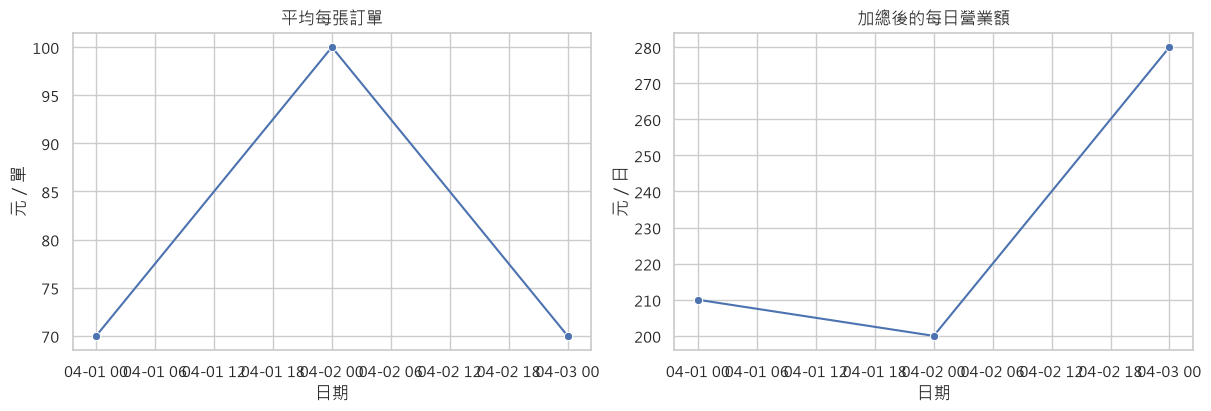

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
	sns.lineplot(data=orders, x="日期", y="訂單金額", estimator="mean", errorbar=None, marker="o", ax=axes[0])
	sns.lineplot(data=daily, x="日期", y="訂單金額", estimator=None, errorbar=None, marker="o", ax=axes[1])
	axes[0].set(title="平均每張訂單", ylabel="元／單")
	axes[1].set(title="加總後的每日營業額", ylabel="元／日")
	plt.show()


### 範例：平均與標準差陰影


獨立範例檔："./Data_Visualization_data/同學通勤紀錄.csv"

平均時間之外，同組同學之間差多少？本例的陰影表示平均加減一個標準差。


In [26]:
import pandas as pd

df = pd.read_csv("./Data_Visualization_data/同學通勤紀錄.csv")

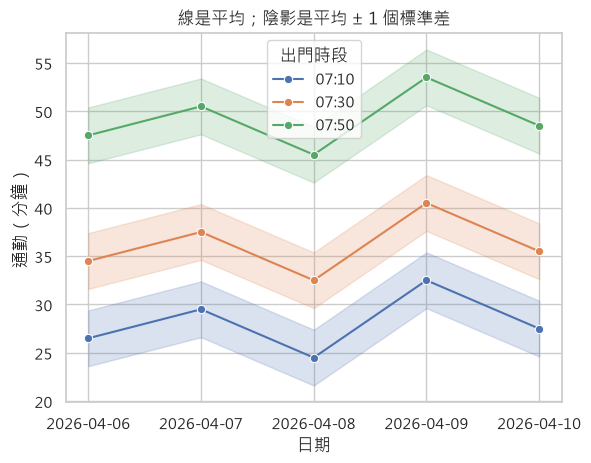

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots()
	sns.lineplot( # 繪製折線圖
		data=df, # 使用 df 作為資料來源
		x="日期", # X 軸使用「日期」欄位
		y="通勤分鐘", # Y 軸使用「通勤分鐘」欄位
		hue="出門時段", # 根據「出門時段」使用不同顏色的折線
		estimator="mean", # 同一天、同一時段有多筆資料時，計算平均值
		errorbar="sd", # 顯示平均值上下 1 個標準差的範圍
		marker="o", # 每個平均值使用圓形標記
		ax=ax # 將圖畫在前面建立的 ax 上
	)
	ax.set(title="線是平均；陰影是平均 ± 1 個標準差", xlabel="日期", ylabel="通勤（分鐘）")

### 範例：每位同學各畫一條線

獨立範例檔："./Data_Visualization_data/散步打卡.csv"

班上散步打卡平均上升，不代表每個人都增加；看看每位同學自己的週次紀錄。


In [29]:
import pandas as pd

df = pd.read_csv("./Data_Visualization_data/散步打卡.csv")
df.head()

,週次,同學,散步天數
0,1,小安,3
1,1,小芬,6
2,1,小豪,1
3,1,小美,4
4,2,小安,4


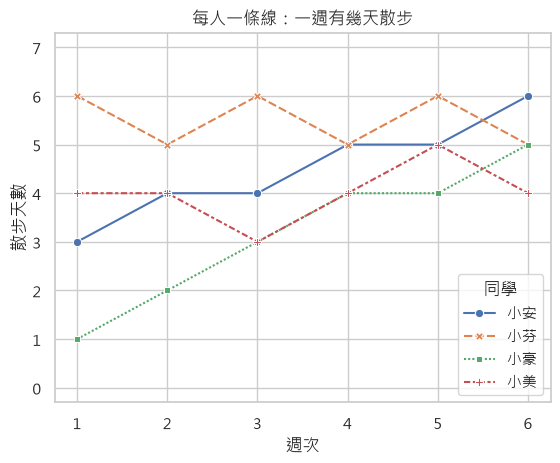

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots()
	sns.lineplot(
		data=df, # 使用 df 作為資料來源
		x="週次", # X 軸使用「週次」
		y="散步天數", # Y 軸使用「散步天數」
		hue="同學", # 不同同學使用不同顏色
		style="同學", # 不同同學使用不同線條與標記樣式
		units="同學", # 以「同學」分組，每位同學的資料各自連成一條線
		estimator=None, # 不計算平均值，直接繪製每位同學的原始資料
		errorbar=None, # 不顯示誤差範圍
		markers=True, # 顯示每個資料點的標記
		ax=ax # 將圖畫在指定的 ax 上
	)
	ax.set(title="每人一條線：一週有幾天散步", xlabel="週次", ylabel="散步天數", ylim=(-0.3, 7.3))
	ax.set_yticks(range(8))
	plt.show()


### 範例：午餐選擇完整報告

獨立範例檔："./Data_Visualization_data/午餐取得方式.csv"

每日費用、十天累積與摘要表，最後寫出帶限制的選擇建議。


In [32]:
import pandas as pd

df = pd.read_csv("./Data_Visualization_data/午餐取得方式.csv")
df

,日期,自備便當,店內購買,外送到家
0,2026-04-06,65,110,165
1,2026-04-07,70,120,180
2,2026-04-08,60,105,160
3,2026-04-09,75,130,195
4,2026-04-10,68,115,170
5,2026-04-11,72,120,185
6,2026-04-12,66,110,165
7,2026-04-13,70,125,190
8,2026-04-14,65,115,175
9,2026-04-15,74,130,200


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


### 將寬格式轉成長格式
methods = ["自備便當", "店內購買", "外送到家"]
long = df.melt(
	id_vars="日期",
	value_vars=methods,
	var_name="方式",
	value_name="費用"
)
long["累積費用"] = long.groupby("方式")["費用"].cumsum() ### 計算每種方式的累積費用
long


,日期,方式,費用,累積費用
0,2026-04-06,自備便當,65,65
1,2026-04-07,自備便當,70,135
2,2026-04-08,自備便當,60,195
3,2026-04-09,自備便當,75,270
4,2026-04-10,自備便當,68,338
5,2026-04-11,自備便當,72,410
6,2026-04-12,自備便當,66,476
7,2026-04-13,自備便當,70,546
8,2026-04-14,自備便當,65,611
9,2026-04-15,自備便當,74,685


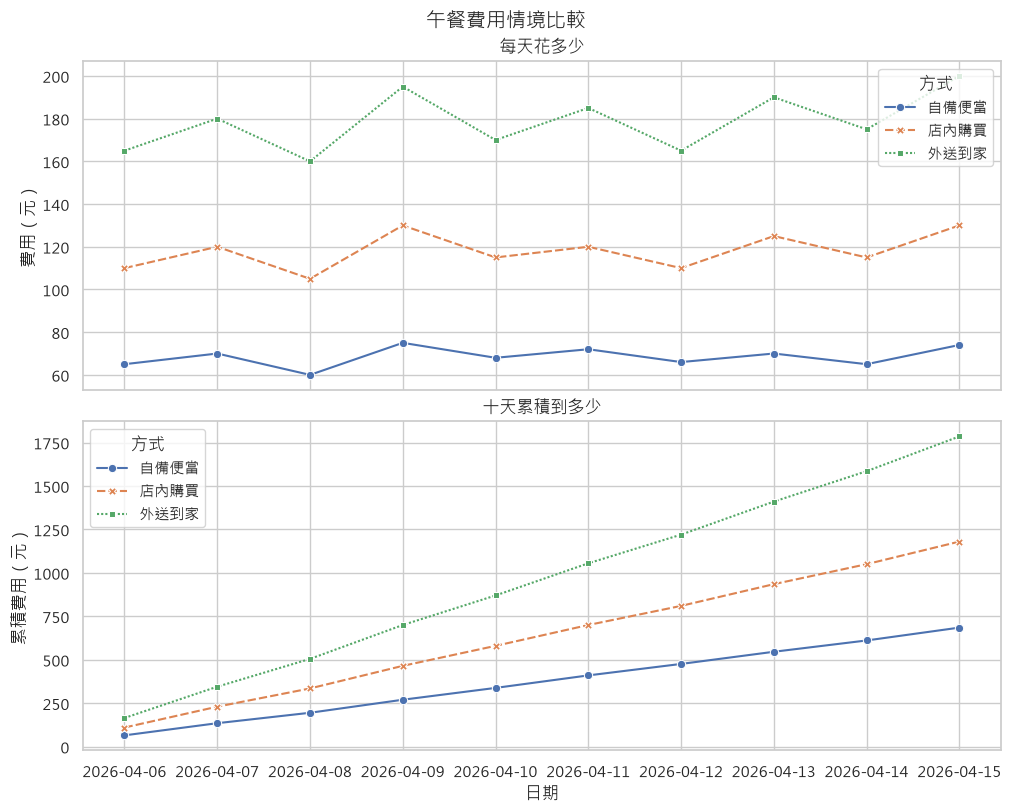

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, layout="constrained")

	# 上圖：每天花多少
	sns.lineplot(
		data=long,
		x="日期",
		y="費用",
		hue="方式",
		style="方式",
		markers=True,
		estimator=None,
		errorbar=None,
		ax=axes[0]
	)

	# 下圖：累積花多少
	sns.lineplot(
		data=long,
		x="日期",
		y="累積費用",
		hue="方式",
		style="方式",
		markers=True, # 顯示每個資料點的標記
		estimator=None,  # 不計算平均值，直接繪製每位同學的原始資料
		errorbar=None, # 不顯示誤差範圍
		ax=axes[1]
	)

	axes[0].set(
		title="每天花多少",
		ylabel="費用（元）"
	)

	axes[1].set(
		title="十天累積到多少",
		xlabel="日期",
		ylabel="累積費用（元）"
	)

	fig.suptitle("午餐費用情境比較")
	plt.show()